# Global GDP Exploratory Data Analysis

Explore GDP data from 1960-2025

### Data source

Data from **Kaggle**

GDP data from 1960-2020, **Ozgur Cem Tas**: https://www.kaggle.com/datasets/zgrcemta/world-gdpgdp-gdp-per-capita-and-annual-growths

GDP data from 2020-2025, **Nadiia**: https://www.kaggle.com/datasets/codebynadiia/gdp-per-country-20202025

In [1]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

In [2]:
# read cleaned CSV file
full_data = pd.read_csv('./data/full_gdp_data_1960_2020.csv')
print(full_data.head())
print(full_data.tail())

       Country  Year   GDP
0        Aruba  1960   NaN
1  Afghanistan  1960  0.54
2       Angola  1960   NaN
3      Albania  1960   NaN
4      Andorra  1960   NaN
         Country  Year     GDP
11371    Vietnam  2025  490.97
11372  Palestine  2025     NaN
11373      Yemen  2025   17.40
11374     Zambia  2025   28.91
11375   Zimbabwe  2025   38.17


In [3]:
# Create the chart
fig = px.line(full_data, x="Year", y="GDP", color="Country", hover_name="Country", title="GDP Growth of Countries (1960-2020)")

# Remove the permanent legend
fig.update_layout(showlegend=False)

fig.show()

## Section 1 — Data Quality & Missing Values

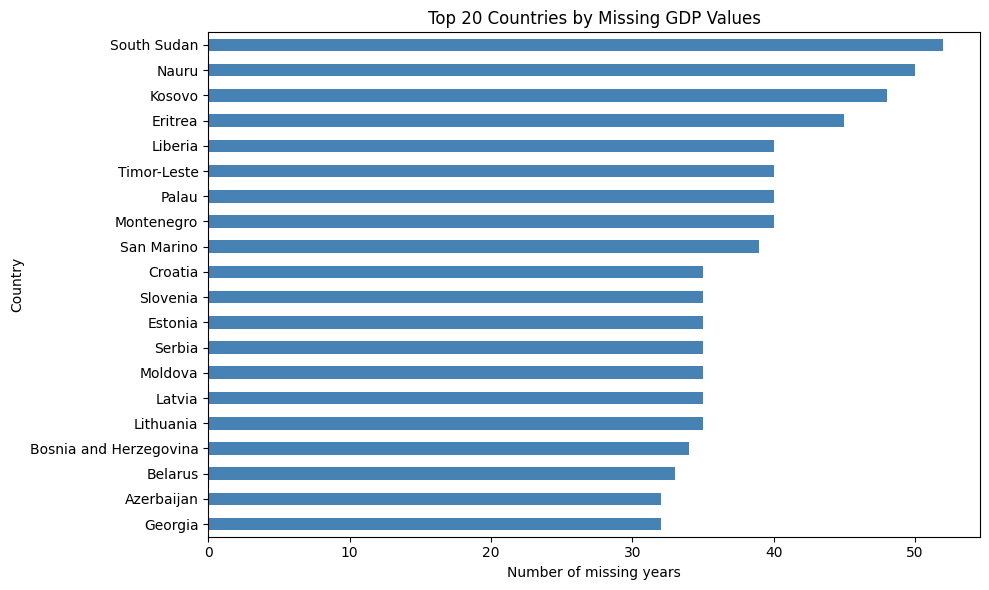

In [4]:
# Missing count per country — top 20
missing_by_country = full_data[full_data['GDP'].isna()].groupby('Country').size().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
missing_by_country.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Countries by Missing GDP Values')
ax.set_xlabel('Number of missing years')
plt.tight_layout()
plt.show()

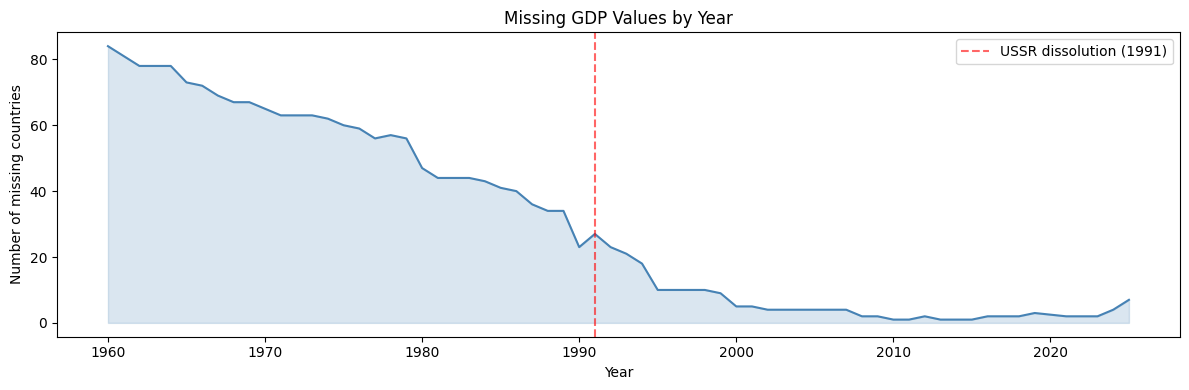

In [5]:
# Missing count per year
missing_by_year = full_data[full_data['GDP'].isna()].groupby('Year').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(missing_by_year.index, missing_by_year.values, color='steelblue', linewidth=1.5)
ax.fill_between(missing_by_year.index, missing_by_year.values, alpha=0.2, color='steelblue')
ax.axvline(1991, color='red', linestyle='--', alpha=0.6, label='USSR dissolution (1991)')
ax.set_title('Missing GDP Values by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of missing countries')
ax.legend()
plt.tight_layout()
plt.show()

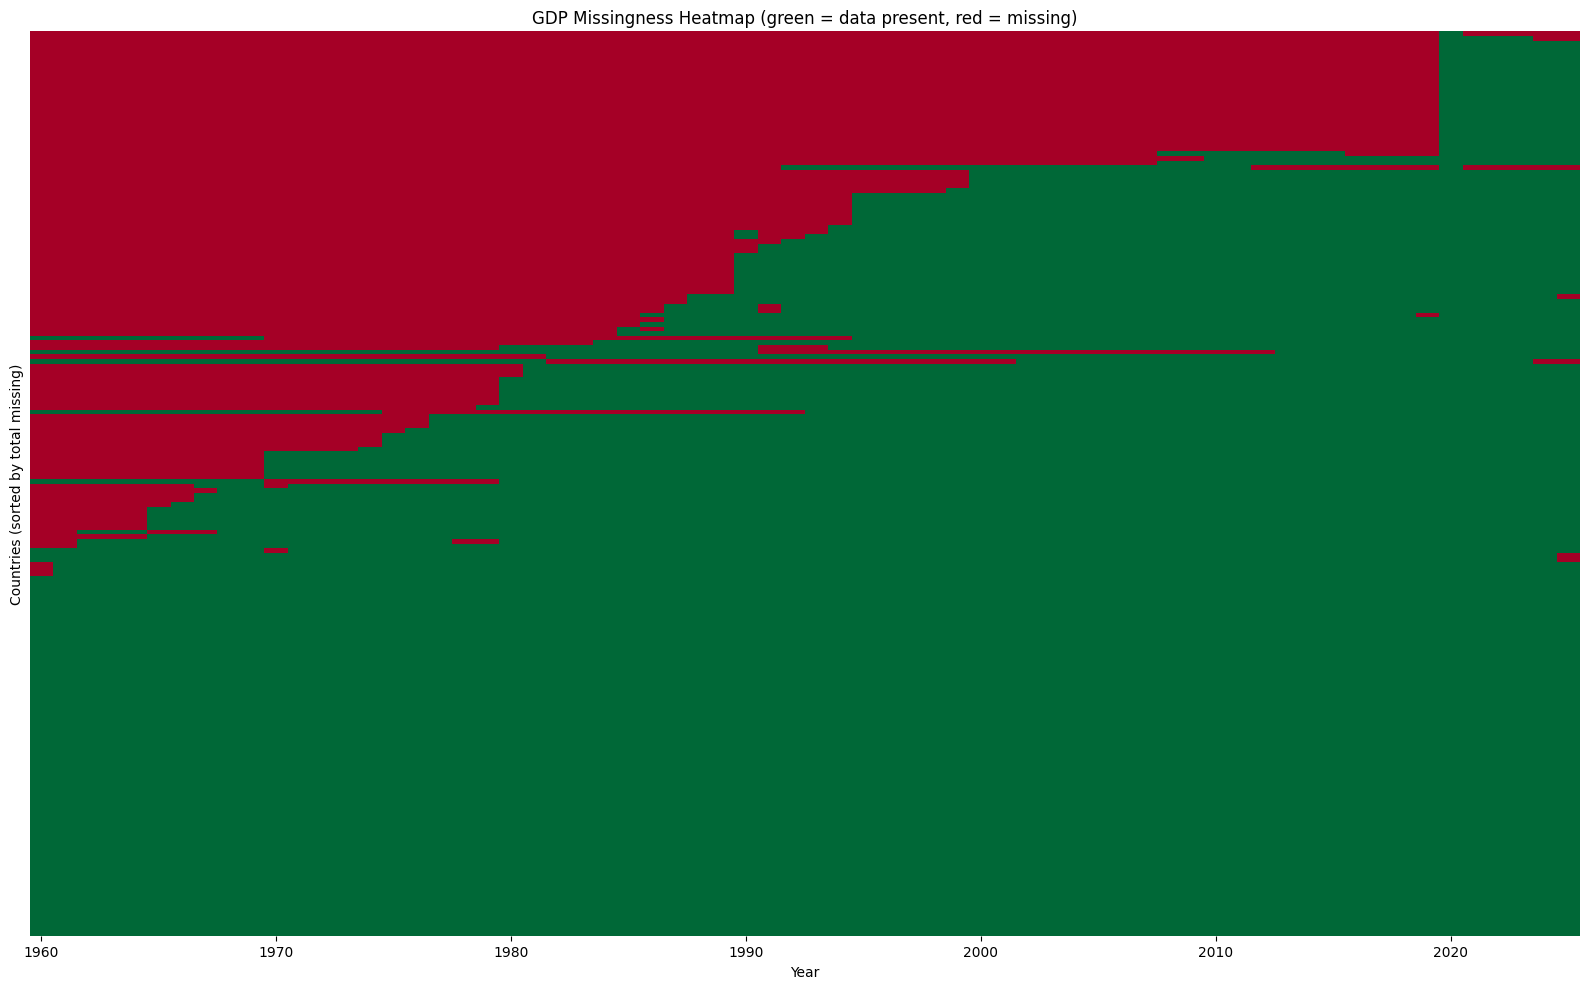

In [6]:
# Missingness heatmap: countries (sorted by total nulls) x years
pivot = full_data.pivot(index='Country', columns='Year', values='GDP')
is_missing = pivot.isna().astype(int)  # 1 = missing

country_order = is_missing.sum(axis=1).sort_values(ascending=False).index
is_missing_sorted = is_missing.loc[country_order]

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(is_missing_sorted, cmap='RdYlGn_r', cbar=False,
            xticklabels=10, yticklabels=False, ax=ax)
ax.set_title('GDP Missingness Heatmap (green = data present, red = missing)')
ax.set_xlabel('Year')
ax.set_ylabel('Countries (sorted by total missing)')
plt.tight_layout()
plt.show()

**Missing data note:** 1,990 null values (~17% of rows) are **not imputed**. They represent genuine absence of statistical reporting — predominantly small island nations and post-Soviet/post-colonial states in early decades. Treating them as zeros would severely distort growth and aggregate calculations.

## Section 2 — Summary Statistics & Distribution

In [7]:
# Descriptive stats and world GDP totals
print('=== Dataset overview ===')
print(f'Rows: {len(full_data):,}  |  Countries: {full_data["Country"].nunique()}  |  Years: {full_data["Year"].min()}–{full_data["Year"].max()}')
print(f'Null GDP values: {full_data["GDP"].isna().sum():,}')
print()
print(full_data['GDP'].describe().rename('GDP (billions USD)').to_frame().round(2))
print()
world_gdp = full_data.groupby('Year')['GDP'].sum()
print(f'World GDP 1960: ${world_gdp[1960]:.0f}B  |  2024: ${world_gdp[2024]:.0f}B  |  ~{world_gdp[2024]/world_gdp[1960]:.0f}x growth')

=== Dataset overview ===
Rows: 11,376  |  Countries: 196  |  Years: 1960–2025
Null GDP values: 1,990

       GDP (billions USD)
count             9386.00
mean               238.85
std               1267.12
min                  0.01
25%                  1.91
50%                 11.40
75%                 70.64
max              30507.22

World GDP 1960: $1116B  |  2024: $110532B  |  ~99x growth


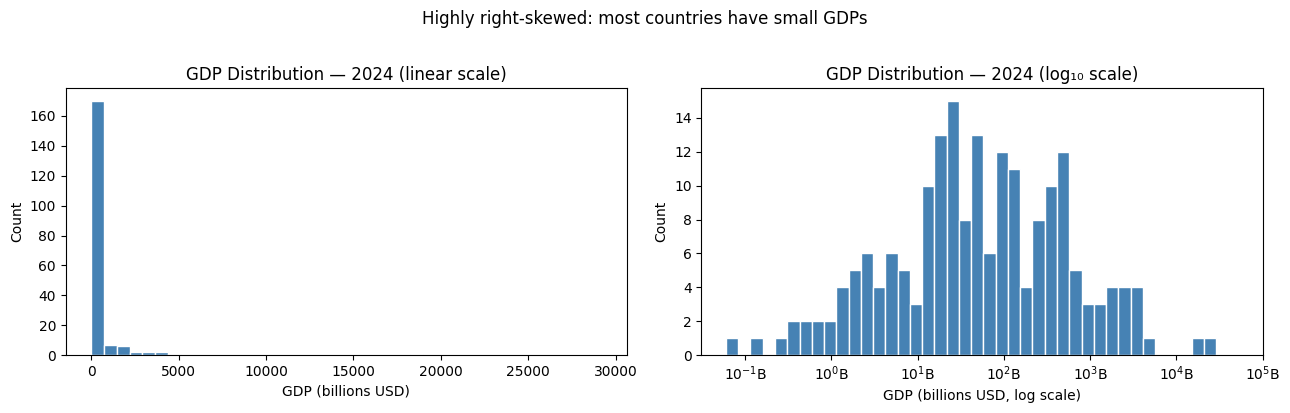

In [8]:
# GDP distribution in 2024 — linear vs log-scale histogram
gdp_2024 = full_data[full_data['Year'] == 2024]['GDP'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gdp_2024, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('GDP Distribution — 2024 (linear scale)')
axes[0].set_xlabel('GDP (billions USD)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log10(gdp_2024), bins=40, color='steelblue', edgecolor='white')
axes[1].set_xticks(range(-1, 6))
axes[1].set_xticklabels([f'$10^{{{i}}}$B' for i in range(-1, 6)])
axes[1].set_title('GDP Distribution — 2024 (log₁₀ scale)')
axes[1].set_xlabel('GDP (billions USD, log scale)')
axes[1].set_ylabel('Count')

plt.suptitle('Highly right-skewed: most countries have small GDPs', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Nikla_000\AppData\Local\Temp\ipykernel_9284\2430201295.py:9: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



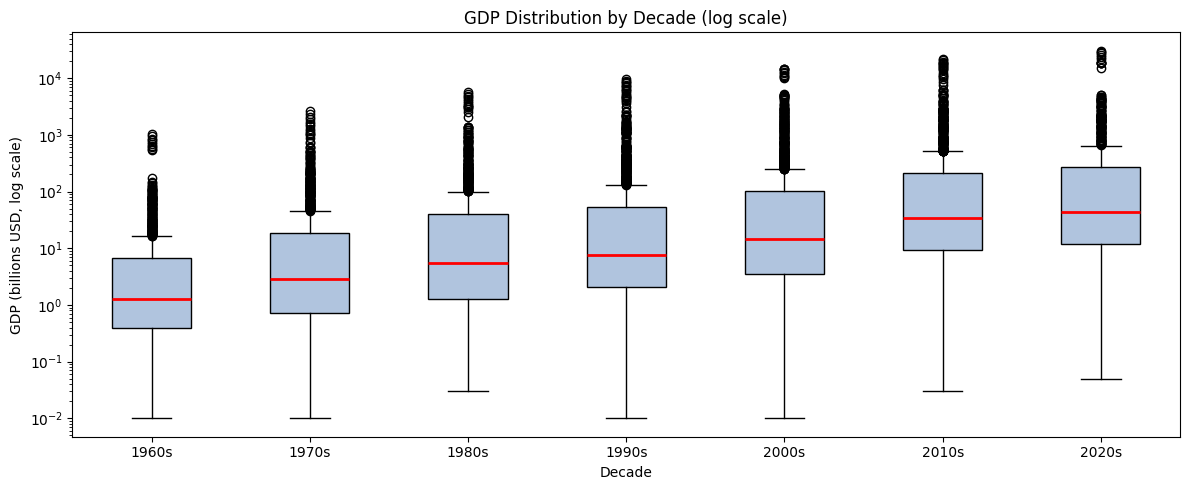

In [9]:
# Box plots by decade — log scale
full_data['Decade'] = (full_data['Year'] // 10) * 10

fig, ax = plt.subplots(figsize=(12, 5))
decade_groups = [full_data[full_data['Decade'] == d]['GDP'].dropna().values
                 for d in sorted(full_data['Decade'].unique())]
decade_labels = [f'{d}s' for d in sorted(full_data['Decade'].unique())]

bp = ax.boxplot(decade_groups, labels=decade_labels, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
ax.set_yscale('log')
ax.set_title('GDP Distribution by Decade (log scale)')
ax.set_xlabel('Decade')
ax.set_ylabel('GDP (billions USD, log scale)')
plt.tight_layout()
plt.show()

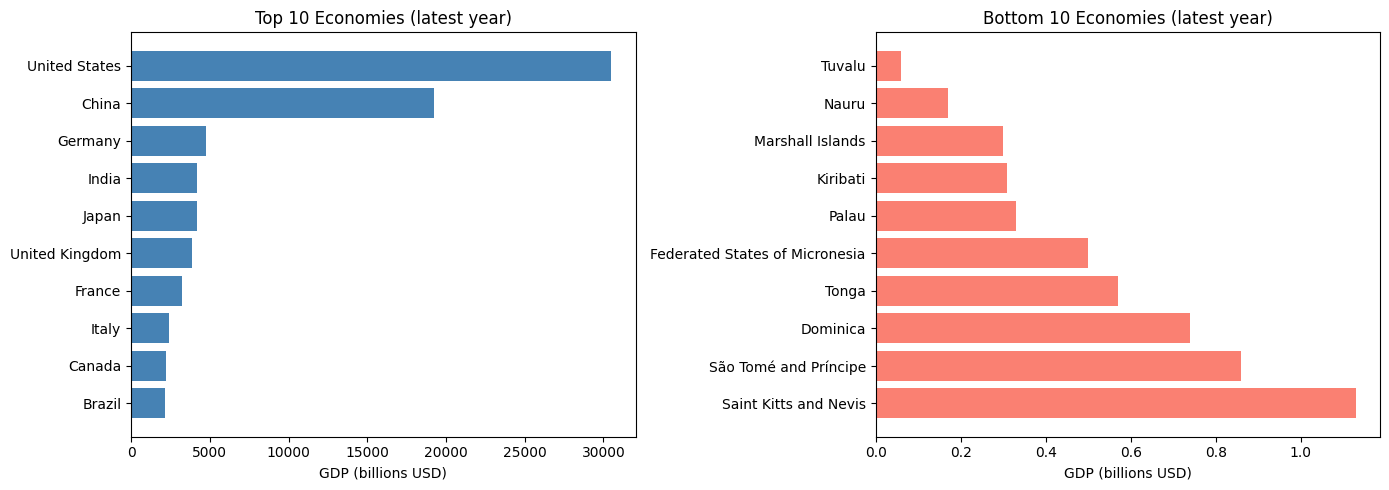

In [10]:
# Top 10 and Bottom 10 by latest available GDP
latest_gdp = (full_data.dropna(subset=['GDP'])
              .sort_values('Year')
              .groupby('Country', as_index=False)
              .last())[['Country', 'Year', 'GDP']].sort_values('GDP', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10 = latest_gdp.head(10).sort_values('GDP')
axes[0].barh(top10['Country'], top10['GDP'], color='steelblue')
axes[0].set_title('Top 10 Economies (latest year)')
axes[0].set_xlabel('GDP (billions USD)')

bot10 = latest_gdp.tail(10).sort_values('GDP', ascending=False)
axes[1].barh(bot10['Country'], bot10['GDP'], color='salmon')
axes[1].set_title('Bottom 10 Economies (latest year)')
axes[1].set_xlabel('GDP (billions USD)')

plt.tight_layout()
plt.show()

## Section 3 — Global Temporal Trends

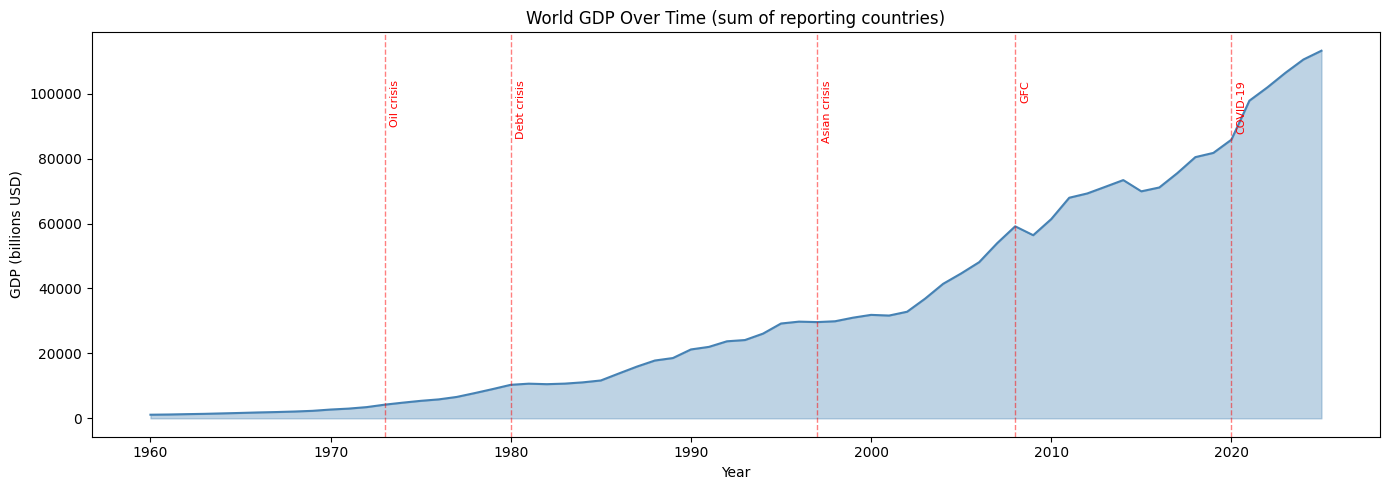

In [11]:
# World GDP over time — area chart with economic shock annotations
world_gdp = full_data.groupby('Year')['GDP'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(world_gdp['Year'], world_gdp['GDP'], alpha=0.35, color='steelblue')
ax.plot(world_gdp['Year'], world_gdp['GDP'], color='steelblue', linewidth=1.5)

shocks = {1973: 'Oil crisis', 1980: 'Debt crisis', 1997: 'Asian crisis',
          2008: 'GFC', 2020: 'COVID-19'}
for yr, label in shocks.items():
    ax.axvline(yr, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(yr + 0.3, world_gdp['GDP'].max() * 0.92, label,
            rotation=90, fontsize=8, color='red', va='top')

ax.set_title('World GDP Over Time (sum of reporting countries)')
ax.set_xlabel('Year')
ax.set_ylabel('GDP (billions USD)')
plt.tight_layout()
plt.show()

In [12]:
# Log-scale multi-country line chart — all countries
fig = px.line(full_data, x='Year', y='GDP', color='Country',
              hover_name='Country',
              title='GDP of All Countries 1960-2025 (log scale)',
              log_y=True)
fig.update_layout(showlegend=False, yaxis_title='GDP (billions USD, log scale)')
fig.show()

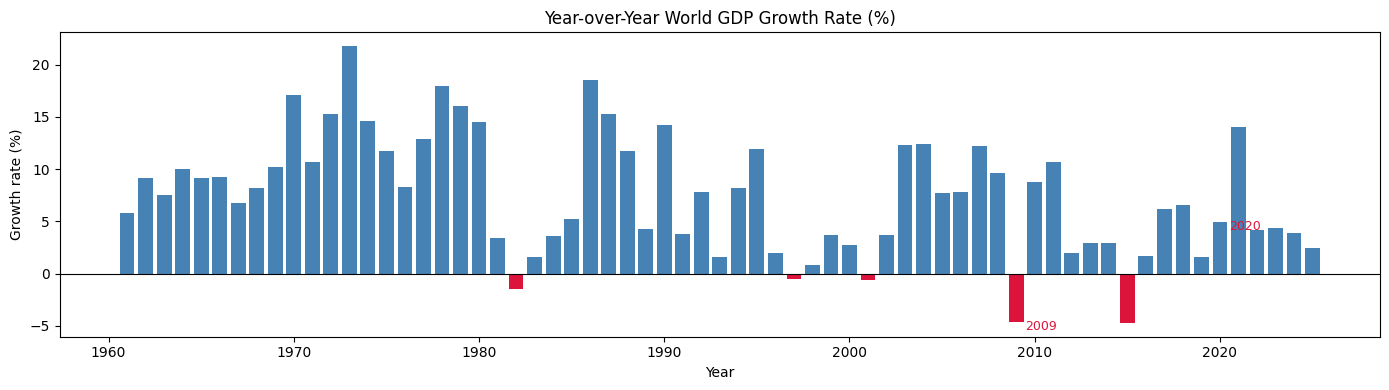

In [13]:
# Year-over-year global GDP growth rate
world_gdp_series = full_data.groupby('Year')['GDP'].sum().sort_index()
yoy = world_gdp_series.pct_change() * 100

colors = ['crimson' if v < 0 else 'steelblue' for v in yoy]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(yoy.index, yoy.values, color=colors, width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
for yr in [2009, 2020]:
    ax.annotate(str(yr), xy=(yr, yoy[yr]), xytext=(yr + 0.5, yoy[yr] - 0.8),
                fontsize=9, color='crimson')
ax.set_title('Year-over-Year World GDP Growth Rate (%)')
ax.set_xlabel('Year')
ax.set_ylabel('Growth rate (%)')
plt.tight_layout()
plt.show()

## Section 4 — Growth Analysis

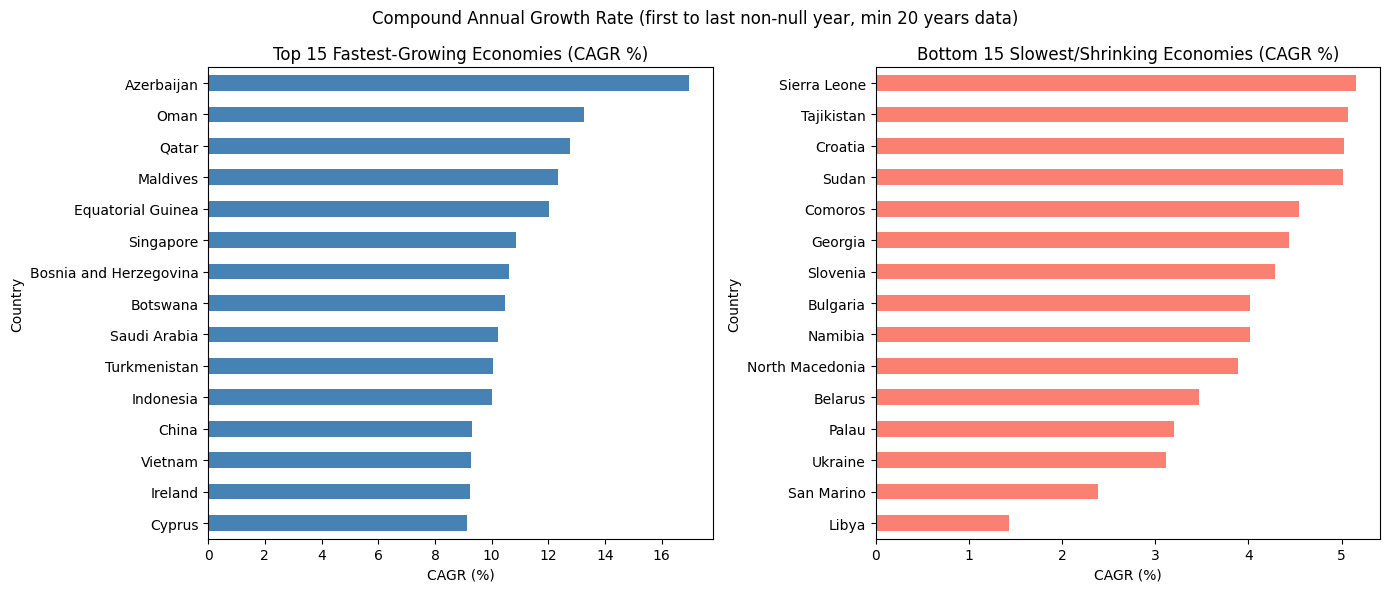

In [14]:
# CAGR per country — top 15 fastest and bottom 15 slowest
def compute_cagr(group):
    g = group.dropna(subset=['GDP']).sort_values('Year')
    if len(g) < 20 or g.iloc[0]['GDP'] <= 0 or g.iloc[-1]['GDP'] <= 0:
        return None
    n = g.iloc[-1]['Year'] - g.iloc[0]['Year']
    if n == 0:
        return None
    return (g.iloc[-1]['GDP'] / g.iloc[0]['GDP']) ** (1 / n) - 1

cagr = full_data.groupby('Country')[['Year', 'GDP']].apply(compute_cagr).dropna().sort_values() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cagr.tail(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Fastest-Growing Economies (CAGR %)')
axes[0].set_xlabel('CAGR (%)')

cagr.head(15).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Bottom 15 Slowest/Shrinking Economies (CAGR %)')
axes[1].set_xlabel('CAGR (%)')

plt.suptitle('Compound Annual Growth Rate (first to last non-null year, min 20 years data)')
plt.tight_layout()
plt.show()

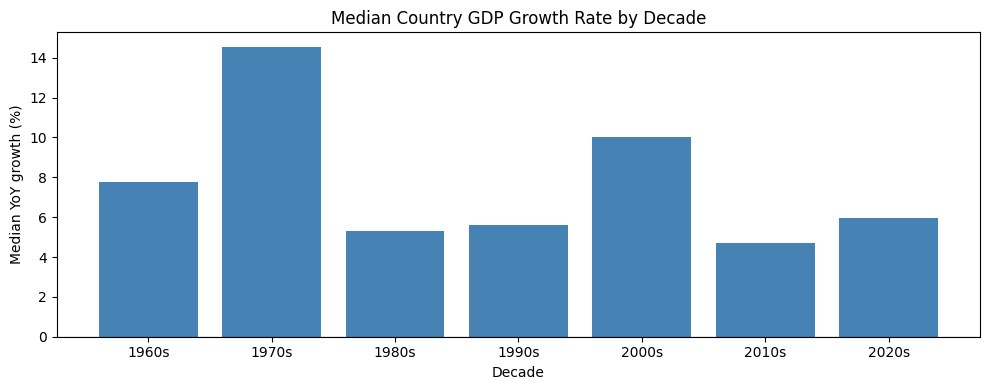

In [15]:
# Decade-by-decade median GDP growth rate
full_data['YoY_pct'] = full_data.sort_values('Year').groupby('Country')['GDP'].pct_change() * 100
full_data['Decade'] = (full_data['Year'] // 10) * 10
median_growth_by_decade = full_data.dropna(subset=['YoY_pct']).groupby('Decade')['YoY_pct'].median()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue' if v >= 0 else 'crimson' for v in median_growth_by_decade]
ax.bar([f'{d}s' for d in median_growth_by_decade.index], median_growth_by_decade.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Median Country GDP Growth Rate by Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Median YoY growth (%)')
plt.tight_layout()
plt.show()

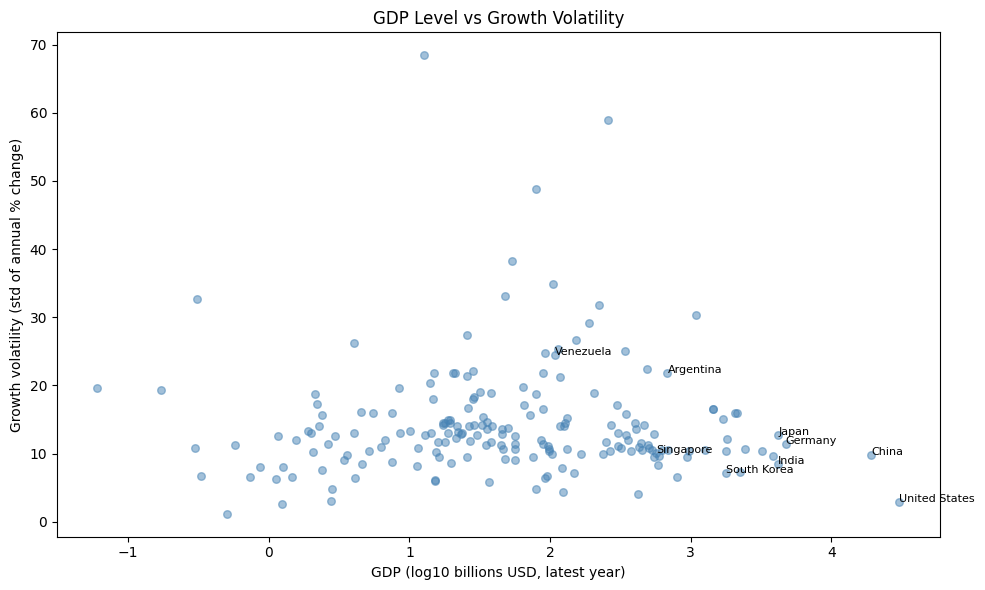

In [16]:
# Growth volatility: latest GDP level (x) vs std of annual % change (y)
latest_gdp_vals = (full_data.dropna(subset=['GDP'])
                   .sort_values('Year')
                   .groupby('Country')['GDP']
                   .last())

volatility = full_data.dropna(subset=['YoY_pct']).groupby('Country')['YoY_pct'].std()
scatter_df = pd.DataFrame({'GDP': latest_gdp_vals, 'Volatility': volatility}).dropna()
scatter_df = scatter_df[scatter_df['GDP'] > 0]

highlight = ['China', 'United States', 'Germany', 'Japan', 'India',
             'Russian Federation', 'Argentina', 'South Korea', 'Singapore', 'Venezuela']

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(np.log10(scatter_df['GDP']), scatter_df['Volatility'],
           alpha=0.5, color='steelblue', s=30)
for c in highlight:
    if c in scatter_df.index:
        ax.annotate(c, (np.log10(scatter_df.loc[c, 'GDP']), scatter_df.loc[c, 'Volatility']),
                    fontsize=8)
ax.set_xlabel('GDP (log10 billions USD, latest year)')
ax.set_ylabel('Growth volatility (std of annual % change)')
ax.set_title('GDP Level vs Growth Volatility')
plt.tight_layout()
plt.show()

## Section 5 — Concentration & Inequality

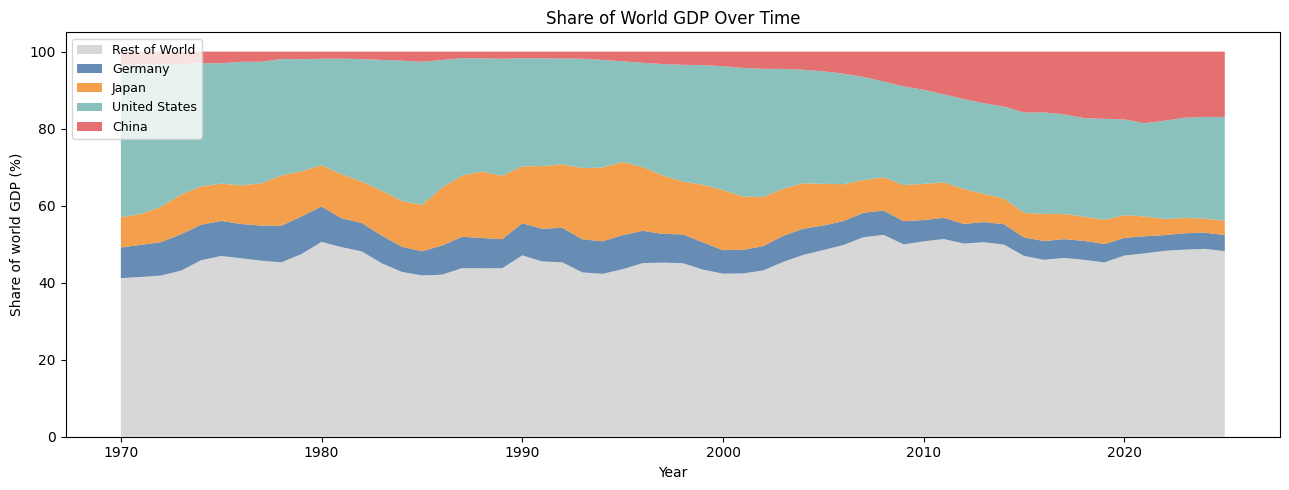

In [17]:
# Share of world GDP — stacked area: US, China, Germany, Japan, Rest
focus = ['United States', 'China', 'Germany', 'Japan']
world_total = full_data.groupby('Year')['GDP'].sum()

share_df = {}
for c in focus:
    cdata = full_data[full_data['Country'] == c].set_index('Year')['GDP']
    share_df[c] = (cdata / world_total * 100).dropna()

share_df['Rest of World'] = 100 - sum(share_df[c] for c in focus)
share_df = pd.DataFrame(share_df).dropna()

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(share_df.index,
             share_df['Rest of World'], share_df['Germany'],
             share_df['Japan'], share_df['United States'], share_df['China'],
             labels=['Rest of World', 'Germany', 'Japan', 'United States', 'China'],
             colors=['#d0d0d0', '#4e79a7', '#f28e2b', '#76b7b2', '#e15759'],
             alpha=0.85)
ax.set_title('Share of World GDP Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Share of world GDP (%)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

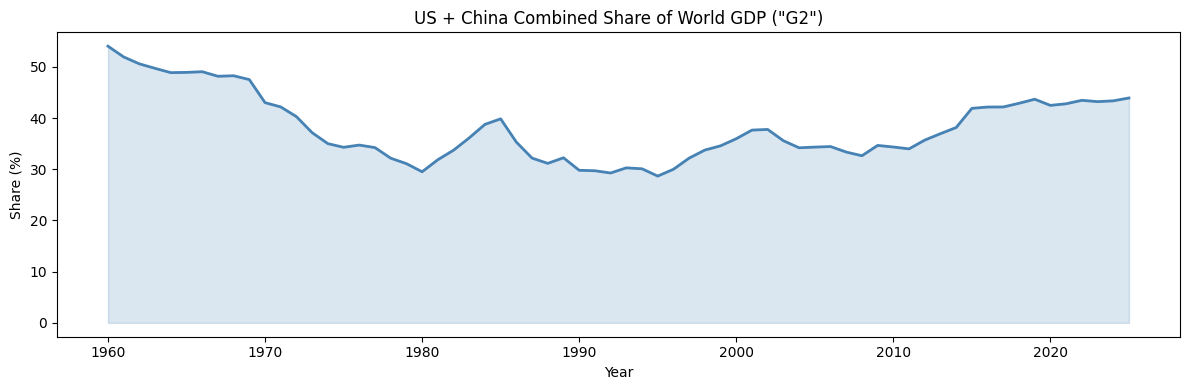

In [18]:
# US + China combined share of world GDP
world_total = full_data.groupby('Year')['GDP'].sum()
us_share = full_data[full_data['Country'] == 'United States'].set_index('Year')['GDP'] / world_total * 100
china_share = full_data[full_data['Country'] == 'China'].set_index('Year')['GDP'] / world_total * 100
g2_share = (us_share + china_share).dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(g2_share.index, g2_share.values, color='steelblue', linewidth=2)
ax.fill_between(g2_share.index, g2_share.values, alpha=0.2, color='steelblue')
ax.set_title('US + China Combined Share of World GDP ("G2")')
ax.set_xlabel('Year')
ax.set_ylabel('Share (%)')
plt.tight_layout()
plt.show()

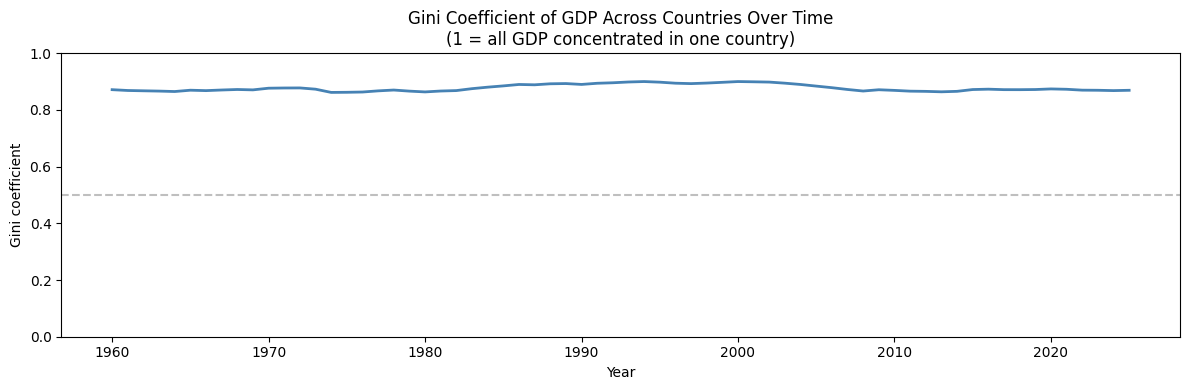

In [19]:
# Gini coefficient of GDP distribution across countries — by year
def gini(arr):
    arr = np.sort(arr[~np.isnan(arr)])
    n = len(arr)
    if n < 2 or arr.sum() == 0:
        return np.nan
    return (2 * np.sum(np.arange(1, n + 1) * arr) / (n * arr.sum())) - (n + 1) / n

gini_by_year = full_data.groupby('Year')['GDP'].apply(gini)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(gini_by_year.index, gini_by_year.values, color='steelblue', linewidth=2)
ax.set_ylim(0, 1)
ax.set_title('Gini Coefficient of GDP Across Countries Over Time\n(1 = all GDP concentrated in one country)')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Section 6 — Notable Country Trajectories

In [20]:
# China's rise vs USA (log scale)
sel = full_data[full_data['Country'].isin(['China', 'United States'])]
fig = px.line(sel, x='Year', y='GDP', color='Country',
              title='China vs United States — GDP 1960–2025 (log scale)',
              log_y=True)
fig.add_vline(x=1978, line_dash='dash', line_color='gray',
              annotation_text='Reform & Opening 1978', annotation_position='top right')
fig.add_vline(x=2001, line_dash='dash', line_color='gray', annotation_text='WTO 2001')
fig.add_vline(x=2008, line_dash='dash', line_color='gray', annotation_text='GFC 2008')
fig.update_layout(yaxis_title='GDP (billions USD, log scale)')
fig.show()

In [21]:
# Asian Tigers
tigers = ['South Korea', 'Singapore', 'Hong Kong SAR, China']
tigers_present = [c for c in tigers if c in full_data['Country'].values]
sel = full_data[full_data['Country'].isin(tigers_present)]
fig = px.line(sel, x='Year', y='GDP', color='Country',
              title='Asian Tigers — Explosive Growth 1960–2025')
fig.update_layout(yaxis_title='GDP (billions USD)')
fig.show()

In [22]:
# Japan's Lost Decades
sel = full_data[full_data['Country'] == 'Japan']
fig = px.line(sel, x='Year', y='GDP',
              title="Japan — Economic Miracle then Lost Decades")
fig.add_vline(x=1985, line_dash='dash', line_color='orange',
              annotation_text='Plaza Accord 1985')
fig.add_vline(x=1991, line_dash='dash', line_color='red',
              annotation_text='Bubble bust 1991')
fig.update_layout(yaxis_title='GDP (billions USD)')
fig.show()

In [23]:
# Post-Soviet transitions
post_soviet = ['Russian Federation', 'Ukraine', 'Kazakhstan']
post_soviet_present = [c for c in post_soviet if c in full_data['Country'].values]
sel = full_data[(full_data['Country'].isin(post_soviet_present)) & (full_data['Year'] >= 1988)]
fig = px.line(sel, x='Year', y='GDP', color='Country',
              title='Post-Soviet Transitions — GDP 1988–2025')
fig.add_vline(x=1991, line_dash='dash', line_color='red', annotation_text='USSR dissolved 1991')
fig.add_vline(x=1998, line_dash='dash', line_color='orange', annotation_text='Russian default 1998')
fig.update_layout(yaxis_title='GDP (billions USD)')
fig.show()

In [24]:
# Latin America
latam = ['Brazil', 'Mexico', 'Argentina']
sel = full_data[full_data['Country'].isin(latam)]
fig = px.line(sel, x='Year', y='GDP', color='Country',
              title='Latin America — Brazil, Mexico, Argentina 1960–2025')
fig.add_vline(x=1982, line_dash='dash', line_color='red', annotation_text='Debt crisis 1982')
fig.add_vline(x=2001, line_dash='dash', line_color='orange', annotation_text='Argentina default 2001')
fig.update_layout(yaxis_title='GDP (billions USD)')
fig.show()

## Section 7 — Economic Shocks Deep Dive

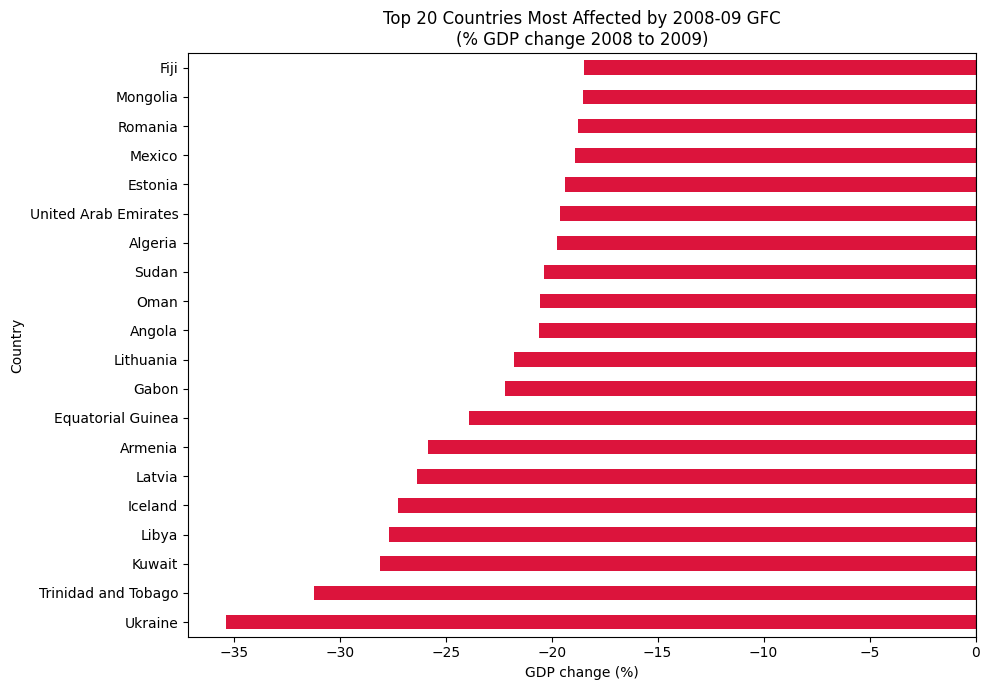

In [25]:
# 2008-09 GFC: % GDP change per country
gdp_2008 = full_data[full_data['Year'] == 2008].set_index('Country')['GDP']
gdp_2009 = full_data[full_data['Year'] == 2009].set_index('Country')['GDP']
gfc_drop = ((gdp_2009 - gdp_2008) / gdp_2008 * 100).dropna().sort_values()

top20_hit = gfc_drop.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20_hit.sort_values(ascending=True).plot(kind='barh', ax=ax, color='crimson')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Countries Most Affected by 2008-09 GFC\n(% GDP change 2008 to 2009)')
ax.set_xlabel('GDP change (%)')
plt.tight_layout()
plt.show()

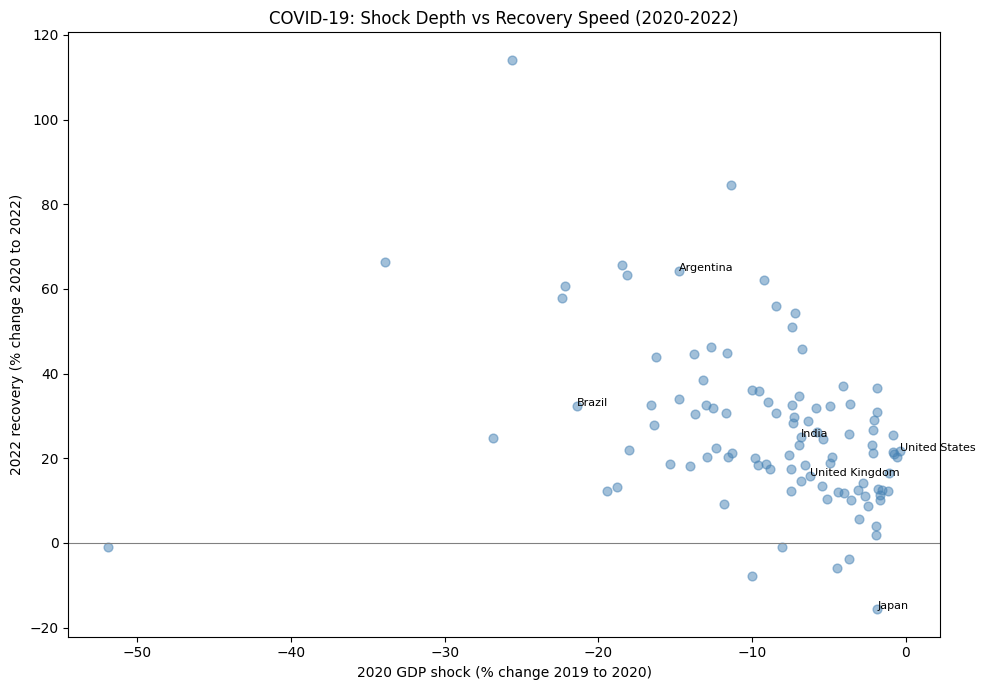

In [26]:
# COVID-19 shock (2019->2020) vs recovery speed (2020->2022)
gdp_2019 = full_data[full_data['Year'] == 2019].set_index('Country')['GDP']
gdp_2020 = full_data[full_data['Year'] == 2020].set_index('Country')['GDP']
gdp_2022 = full_data[full_data['Year'] == 2022].set_index('Country')['GDP']

shock = ((gdp_2020 - gdp_2019) / gdp_2019 * 100).rename('shock_pct')
recovery = ((gdp_2022 - gdp_2020) / gdp_2020 * 100).rename('recovery_pct')

covid_df = pd.concat([shock, recovery], axis=1).dropna()
covid_df = covid_df[covid_df['shock_pct'] < 0]

highlight = ['United States', 'China', 'Germany', 'India', 'United Kingdom',
             'Brazil', 'Russian Federation', 'South Korea', 'Argentina', 'Japan']

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(covid_df['shock_pct'], covid_df['recovery_pct'],
           alpha=0.5, color='steelblue', s=40)
for c in highlight:
    if c in covid_df.index:
        ax.annotate(c, (covid_df.loc[c, 'shock_pct'], covid_df.loc[c, 'recovery_pct']),
                    fontsize=8)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel('2020 GDP shock (% change 2019 to 2020)')
ax.set_ylabel('2022 recovery (% change 2020 to 2022)')
ax.set_title('COVID-19: Shock Depth vs Recovery Speed (2020-2022)')
plt.tight_layout()
plt.show()